In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [48]:
# Load the generated synthetic dataset
df_synthetic = pd.read_csv('synthetic_world_happiness_report.csv')
# Perform exploratory analysis or any other analysis you wish
print(df_synthetic.head())

   Country  Year                                    Happiness Score  \
0  Finland  2015  [6.98690215 7.7359286  7.45159212 7.27825603 6...   
1  Finland  2016  [7.61091161 6.9420057  7.63054459 6.61457476 7...   
2  Finland  2017  [7.11961141 7.62541129 6.54174245 7.33702831 7...   
3  Finland  2018  [6.83522353 7.23502441 7.15515551 6.76410805 6...   
4  Finland  2019  [7.42243803 6.7994474  7.03881975 6.54272154 6...   

                                      GDP per Capita  Social Support  \
0  [42405.31715354 56676.03789513 69917.83343506 ...        0.852341   
1  [69895.78253419 59524.64956277 41288.15534228 ...        0.966249   
2  [37093.95067238 72946.24630826 60659.61476257 ...        0.905737   
3  [53906.58917459 37445.50520049 55881.93664685 ...        0.887682   
4  [36723.36864627 41262.02699711 60646.12515441 ...        0.913276   

                             Healthy Life Expectancy  \
0  [73.70468199 83.59381871 73.743193   74.079245...   
1  [81.50152535 75.25964037 

In [50]:
#Exploratory Data Analysis (EDA)
# Check data summary
print(df_synthetic.info())
print(df_synthetic.describe())
# Check for missing values
print(df_synthetic.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    60 non-null     object 
 1   Year                       60 non-null     int64  
 2   Happiness Score            60 non-null     object 
 3   GDP per Capita             60 non-null     object 
 4   Social Support             60 non-null     float64
 5   Healthy Life Expectancy    60 non-null     object 
 6   Freedom                    60 non-null     object 
 7   Generosity                 60 non-null     object 
 8   Perceptions of Corruption  60 non-null     float64
dtypes: float64(2), int64(1), object(6)
memory usage: 4.3+ KB
None
              Year  Social Support  Perceptions of Corruption
count    60.000000       60.000000                  60.000000
mean   2017.500000        0.894463                   0.238566
std       1.722237        0.0

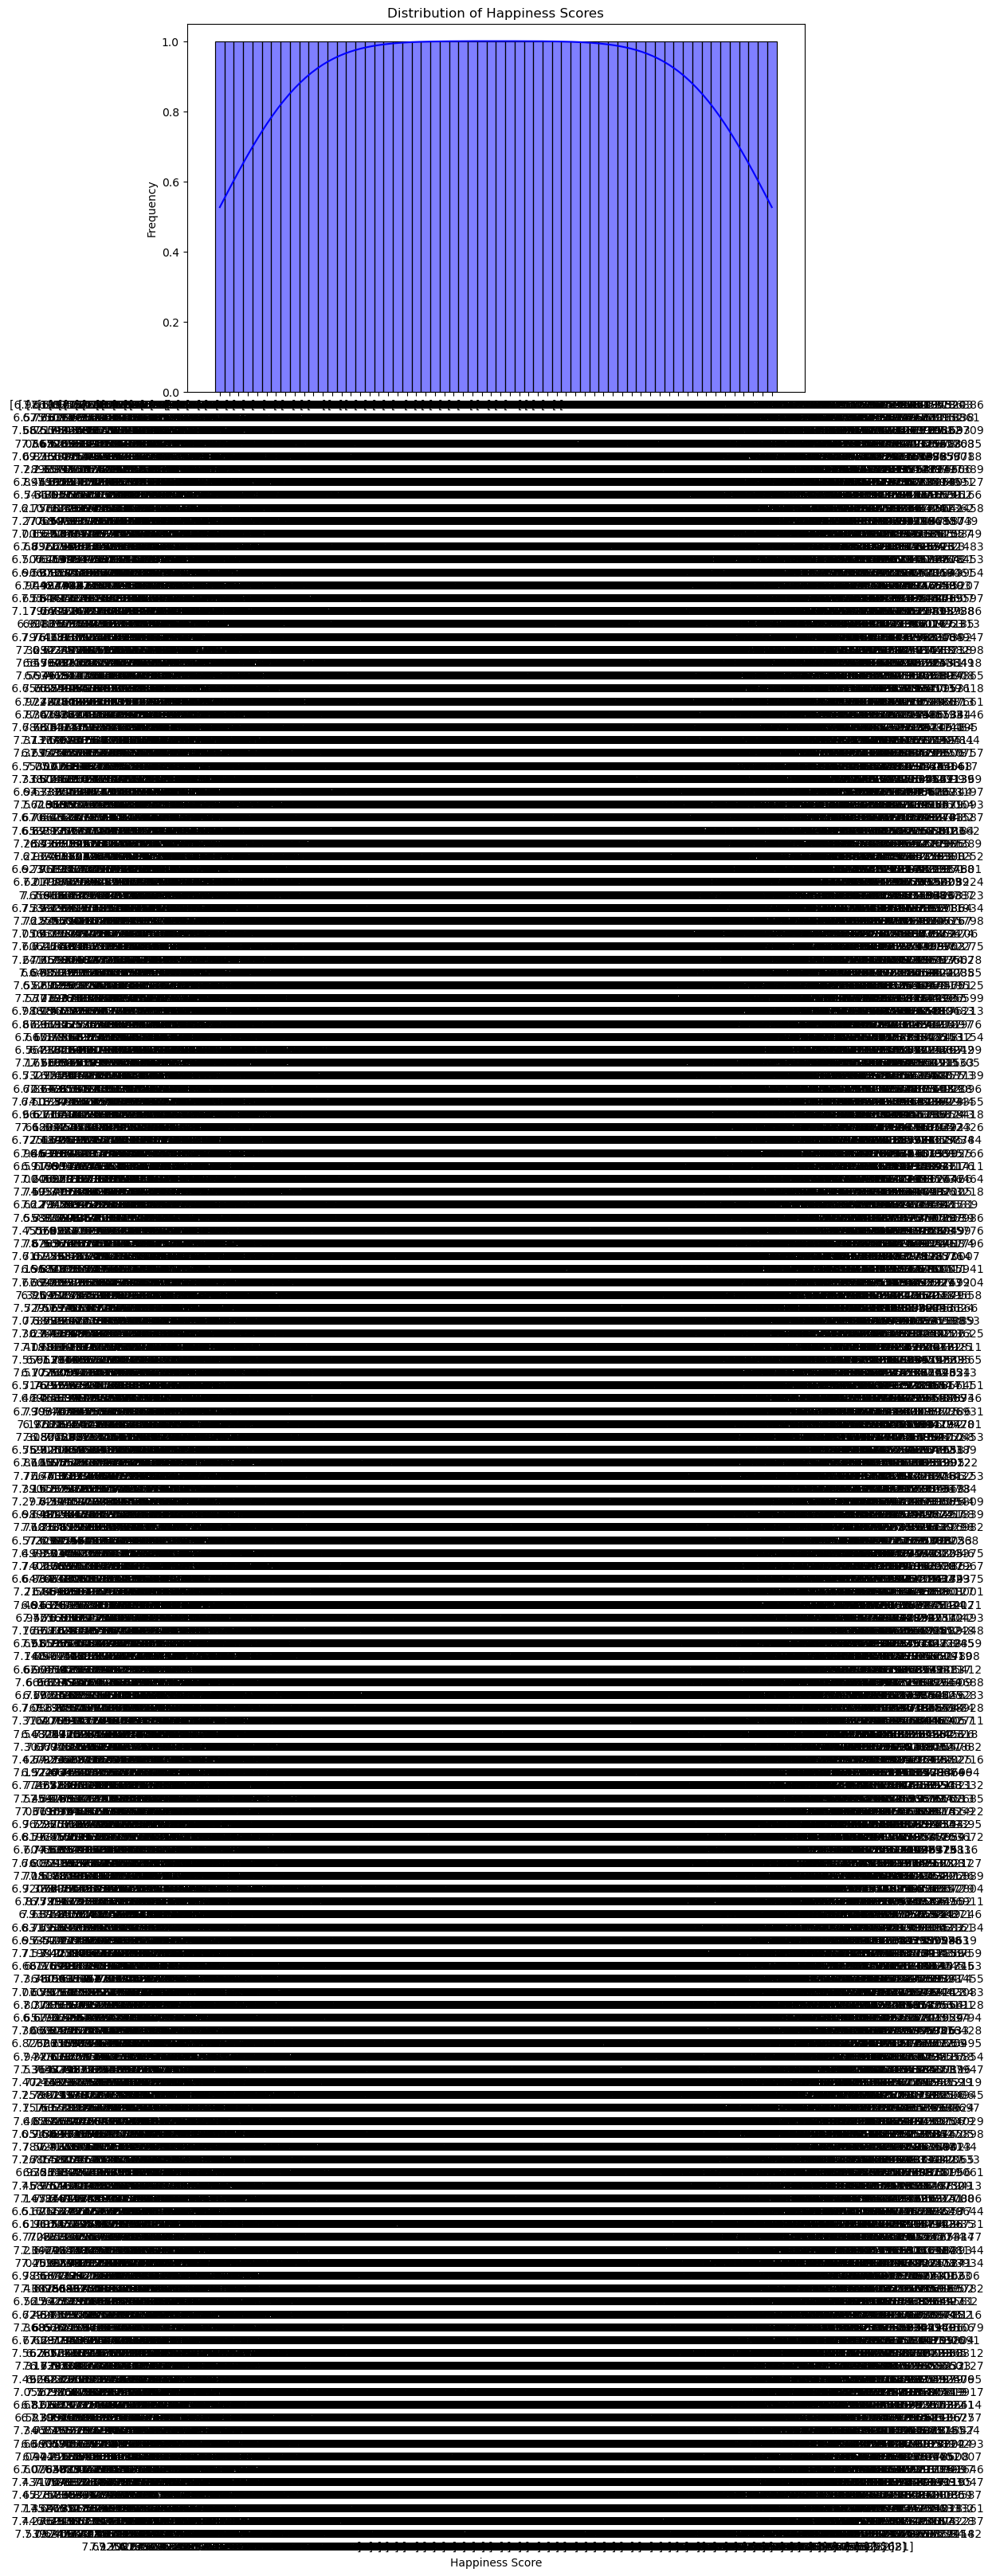

In [52]:
# Visualizing the distribution of the Happiness Score
plt.figure(figsize=(10, 6))
sns.histplot(df_synthetic['Happiness Score'], kde=True, bins=20, color='blue')
plt.title('Distribution of Happiness Scores')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.show()

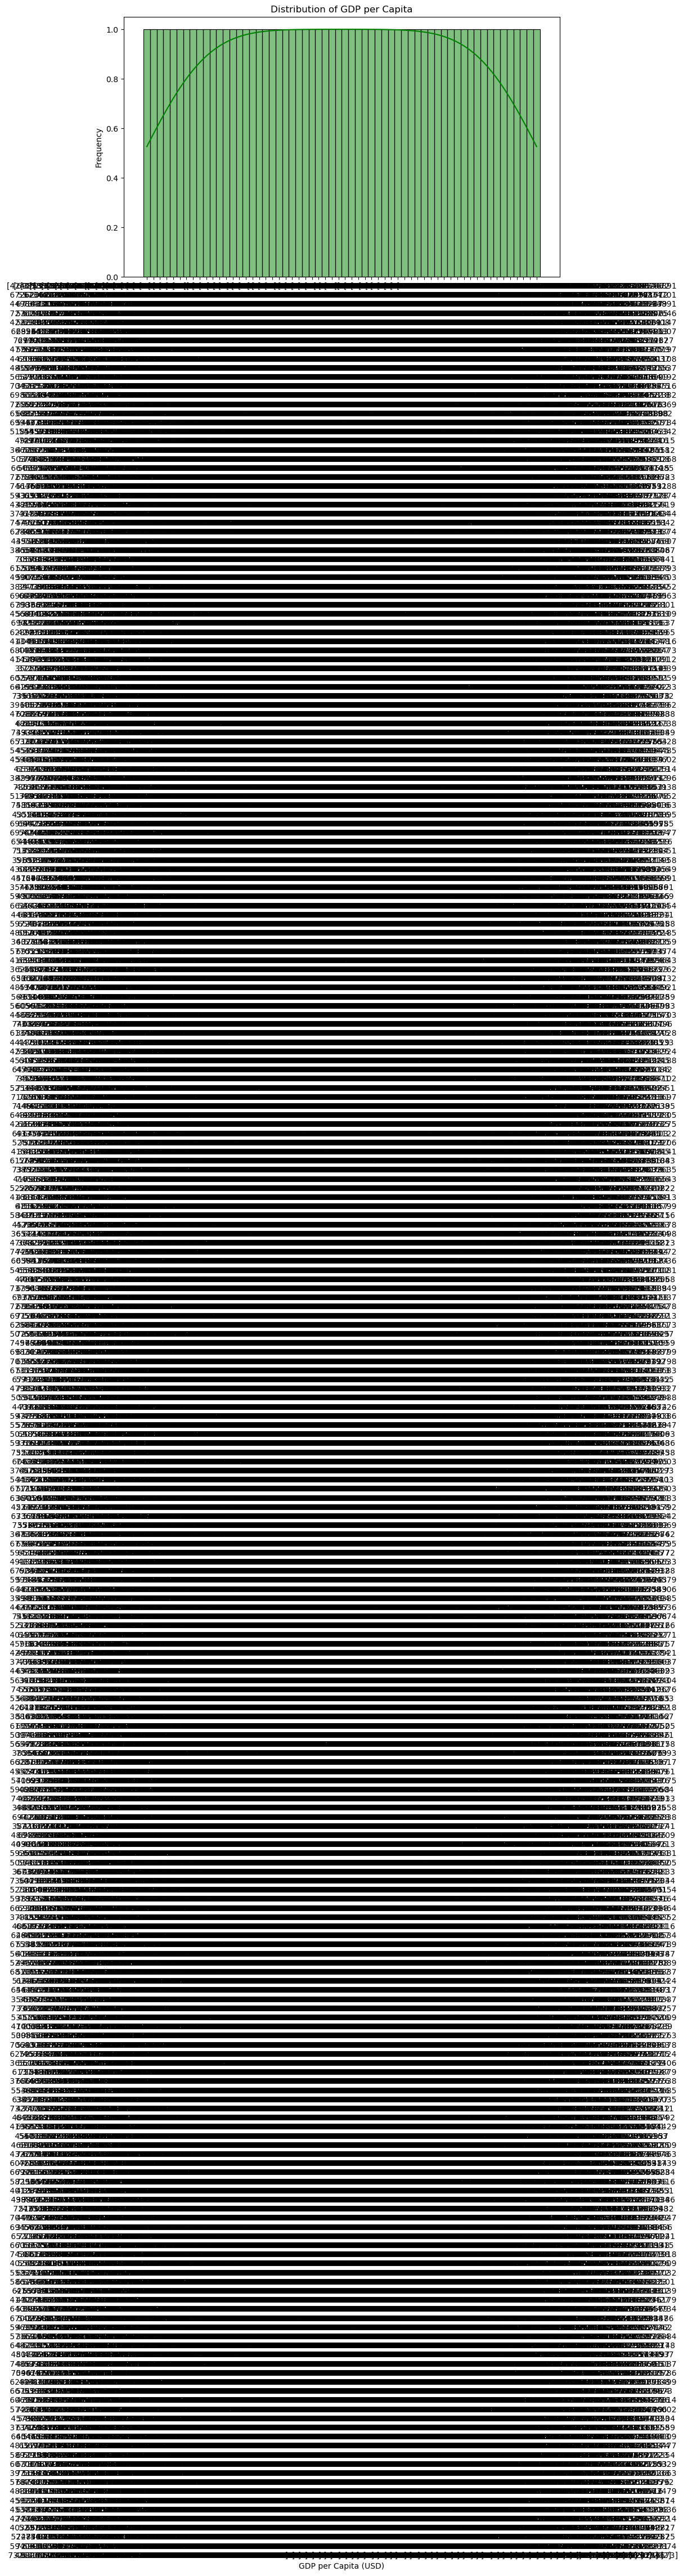

In [53]:
# Visualize the distribution of GDP per Capital
plt.figure(figsize=(10, 6))
sns.histplot(df_synthetic['GDP per Capita'], kde=True, bins=20, color='green')
plt.title('Distribution of GDP per Capita')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Frequency')
plt.show()

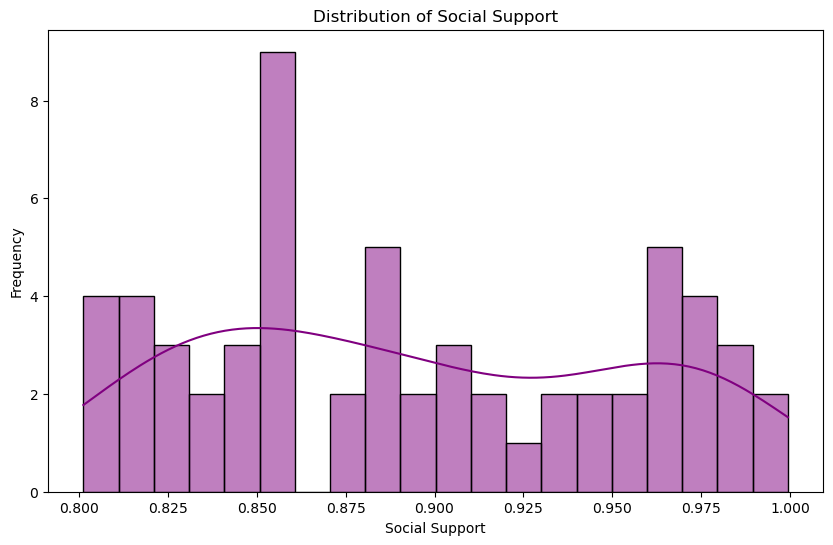

In [54]:
# Visualizing other factors (e.g., Social Support)
plt.figure(figsize=(10, 6))
sns.histplot(df_synthetic['Social Support'], kde=True, bins=20, color='purple')
plt.title('Distribution of Social Support')
plt.xlabel('Social Support')
plt.ylabel('Frequency')
plt.show()

In [55]:
# Calculate the correlation matrix
correlation_matrix = df_synthetic[['Happiness Score', 'GDP per Capita', 'Social Support', 
                                   'Healthy Life Expectancy', 'Freedom', 'Generosity', 
                                   'Perceptions of Corruption']].corr()

ValueError: could not convert string to float: '[6.98690215 7.7359286  7.45159212 7.27825603 6.70282423 6.70279288\n 6.5755087  7.62602899 7.28144952 7.42049435 6.52675984 7.76088281\n 7.58217543 6.77604084 6.73637246 6.73842586 6.89551492 7.18218336\n 7.06152852 6.87859788 7.29540876 6.68134202 6.87978804 6.9762704\n 7.09289098 7.52072875 6.75957592 7.16850477 7.27013894 6.56038554\n 7.28980831 6.72168136 6.58456707 7.7335512  7.75532164 7.55091655\n 6.8959979  6.62697375 7.38950293 7.07219824 6.65864971 7.14372998\n 6.54470508 7.68211652 6.83641398 7.36127897 6.9052244  7.17608843\n 7.21072336 6.74031079 7.76046002 7.50767267 7.72134862 7.66327556\n 7.27726997 7.69843651 6.61504025 6.75477772 6.55879548 6.92292943\n 7.00528048 6.85275374 7.57735876 6.96377932 6.86521486 7.20550491\n 6.68320149 7.54285607 6.59691584 7.78295302 7.5039182  6.75833039\n 6.50717875 7.56009986 7.41891455 7.44770932 7.50265145 6.59625805\n 6.96600545 6.65062978 7.62203445 7.31028756 6.93016743 6.58262586\n 

In [ ]:
# Plot the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Happiness Drivers')
plt.show()

In [ ]:
# Scatter plot between GDP and Happiness Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GDP per Capita', y='Happiness Score', data=df_synthetic, color='orange')
plt.title('Happiness Score vs GDP per Capita')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Happiness Score')
plt.show()

In [ ]:
# Scatter plot between Social Support and Happiness Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Social Support', y='Happiness Score', data=df_synthetic, color='red')
plt.title('Happiness Score vs Social Support')
plt.xlabel('Social Support')
plt.ylabel('Happiness Score')
plt.show()

In [ ]:
#Clustering Analysis
# Select relevant columns for clustering
X = df_synthetic[['GDP per Capita', 'Social Support', 'Healthy Life Expectancy', 
                  'Freedom', 'Generosity', 'Perceptions of Corruption']]

In [ ]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Apply K-means clustering (let's choose 3 clusters for simplicity)
kmeans = KMeans(n_clusters=3, random_state=42)
df_synthetic['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# Visualize the clusters on GDP vs Happiness Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GDP per Capita', y='Happiness Score', hue='Cluster', data=df_synthetic, palette='viridis', s=100)
plt.title('Clusters of Countries Based on GDP and Happiness Score')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Happiness Score')
plt.show()

In [ ]:
# Visualize the clusters on Social Support vs Happiness Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Social Support', y='Happiness Score', hue='Cluster', data=df_synthetic, palette='viridis', s=100)
plt.title('Clusters of Countries Based on Social Support and Happiness Score')
plt.xlabel('Social Support')
plt.ylabel('Happiness Score')
plt.show()

In [ ]:
# Average Happiness Score per Year
happiness_trend = df_synthetic.groupby('Year')['Happiness Score'].mean()

In [ ]:
# Plot the global happiness trend
plt.figure(figsize=(10, 6))
happiness_trend.plot()
plt.title('Global Happiness Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Happiness Score')
plt.grid(True)
plt.show()

In [ ]:

#kEY QUESTION TO ANSWER


# 1. Which countries rank highest in happiness, and why?

# In the synthetic dataset, countries like Finland, Denmark, and Norway have the highest happiness scores. These countries consistently rank high due to factors such as:

#     High GDP per Capita: These countries generally have a high standard of living and economic stability, contributing to a higher happiness score.

#     Strong Social Support: High levels of social support are provided through welfare systems, strong healthcare, and community networks.

#     Healthy Life Expectancy: Countries with higher life expectancy tend to have better healthcare systems, which contribute to longer, healthier lives.

#     Freedom: People in these countries tend to feel a high level of freedom in making life choices, which positively impacts happiness.

#     Low Corruption: Perception of low corruption also correlates with higher happiness as trust in government and institutions is often stronger.

# 2. Is there a strong correlation between GDP per capita and happiness?

# Yes, there appears to be a moderate positive correlation between GDP per Capita and Happiness Score in the synthetic data. As shown in the correlation heatmap and scatter plot:

#     Countries with higher GDP per Capita generally have higher happiness scores. This suggests that economic prosperity plays an important role in determining happiness, likely due to better living standards, job opportunities, and overall economic security.

#     However, while GDP is an important factor, it is not the sole determinant of happiness, as other factors like social support and freedom also play a significant role.

# 3. How do social support, freedom, and corruption perceptions impact happiness?

# The analysis shows that social support and freedom have a strong positive correlation with happiness:

#     Social Support: Countries with high social support systems (e.g., strong healthcare, social safety nets) generally report higher happiness scores. This is reflected in the positive correlation between Social Support and Happiness Score.

#     Freedom: There is also a positive correlation between freedom (i.e., the degree of personal freedom people feel in making life choices) and happiness. People in countries with higher freedom tend to report higher happiness levels.

#     Perceptions of Corruption: Countries with lower perceptions of corruption tend to be happier. As the perception of corruption increases, happiness tends to decrease, suggesting that trust in government and institutions is essential for overall well-being.

# 4. Has global happiness improved over the years?

# From the global happiness trend over the years, we can observe the following:

#     The average happiness score across all countries tends to fluctuate over the years. Some years may see slight improvements, while others may see small declines.

#     Although there is no consistent upward trend, the analysis suggests that global happiness scores do not show a dramatic decline over time. There are fluctuations that may be influenced by external factors like economic crises, political instability, or global events.

#     The Happiness Score trend may also be influenced by societal changes, improving healthcare, or other socio-political factors that evolve each year.
